# Investigação Estatística, Probabilística e Visual -- AB_NYC_2019

### Parte 2: Análise Estatística, Probabilística e Visual

---
### Carregamento do dataset e importção das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import matplotlib.ticker as mticker
from scipy import stats

plt.style.use('ggplot')
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
#00.Carga de Dados -- Dataset
FILE_PATH = '/home/joao/Área de trabalho/New York City Airbnb Open Data/data/data_tratado_01/AB_NYC_2019_20260416.csv'
df_tratado = pd.read_csv(FILE_PATH, encoding='latin-1')

print(f'Dataset carregado: {df_tratado.shape[0]} linhas x {df_tratado.shape[1]} colunas')

Dataset carregado: 45852 linhas x 16 colunas


---
### 4 Análise Univariada (Medidas de Tendência Central, Dispersão e Forma)

In [ ]:
# 4.1 Tendência Central: Calcule Média, Mediana e Moda. Explique qual delas melhor representa o "centro" dos seus dados e por quê.
colunas_numericas = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']

resumo = pd.DataFrame({
    'Média':       df_tratado[colunas_numericas].mean(),
    'Mediana':     df_tratado[colunas_numericas].median(),
    'Moda':        df_tratado[colunas_numericas].mode().iloc[0],
    'Variância':   df_tratado[colunas_numericas].var(),
    'Desvio Padrão': df_tratado[colunas_numericas].std(),
    'Amplitude':   df_tratado[colunas_numericas].max() - df_tratado[colunas_numericas].min(),
    'Assimetria':  df_tratado[colunas_numericas].skew(),
    'Curtose':     df_tratado[colunas_numericas].kurt(),
})
resumo.round(2)

'''
Interpretação:
- price: Média > Mediana, assimetria positiva. A mediana representa melhor o centro pois é menos afetada pelos preços mais altos.  
- minimum_nights: Moda = 1 noite (maioria dos anúncios). Média puxada por valores altos (imóveis com exigência de 30+ dias).  
- number_of_reviews: Assimetria alta a maioria tem poucos reviews, mas alguns anúncios consolidados têm centenas.  
- reviews_per_month: Distribuição muito concentrada próxima a 0 com curtose alta (leptocúrtica).
- availability_365: Distribuição bimodal anúncios quase sempre disponíveis vs. quase nunca disponíveis.  
'''

,Média,Mediana,Moda,Variância,Desvio Padrão,Amplitude,Assimetria,Curtose
price,120.01,100.00,100.0,4641.84,68.13,324.00,0.92,0.17
minimum_nights,6.76,2.00,1.0,256.30,16.01,364.00,11.60,209.94
number_of_reviews,23.89,5.00,0.0,2037.66,45.14,629.00,3.61,18.58
reviews_per_month,1.10,0.38,0.0,2.46,1.57,14.62,2.22,6.60
availability_365,109.34,39.00,0.0,16963.05,130.24,365.00,0.81,-0.91


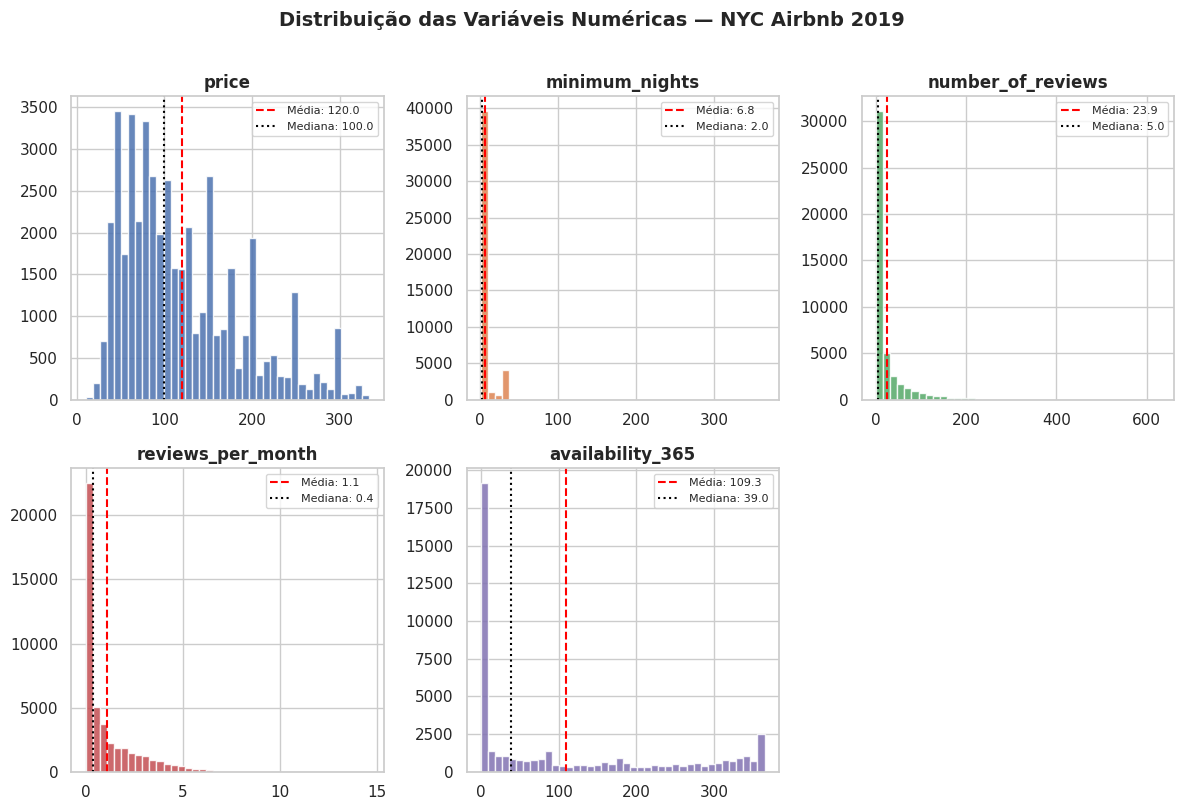

In [4]:
# 4.2 Histogramas Plots da distribuição das variaveis numericas
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

cores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for i, col in enumerate(colunas_numericas):
    media = df_tratado[col].mean()
    mediana = df_tratado[col].median()

    axes[i].hist(df_tratado[col], bins=40, color=cores[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(media,   color='red',    linestyle='--', linewidth=1.5, label=f'Média: {media:.1f}')
    axes[i].axvline(mediana, color='black',  linestyle=':',  linewidth=1.5, label=f'Mediana: {mediana:.1f}')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

fig.delaxes(axes[5])
plt.suptitle('Distribuição das Variáveis Numéricas — NYC Airbnb 2019', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

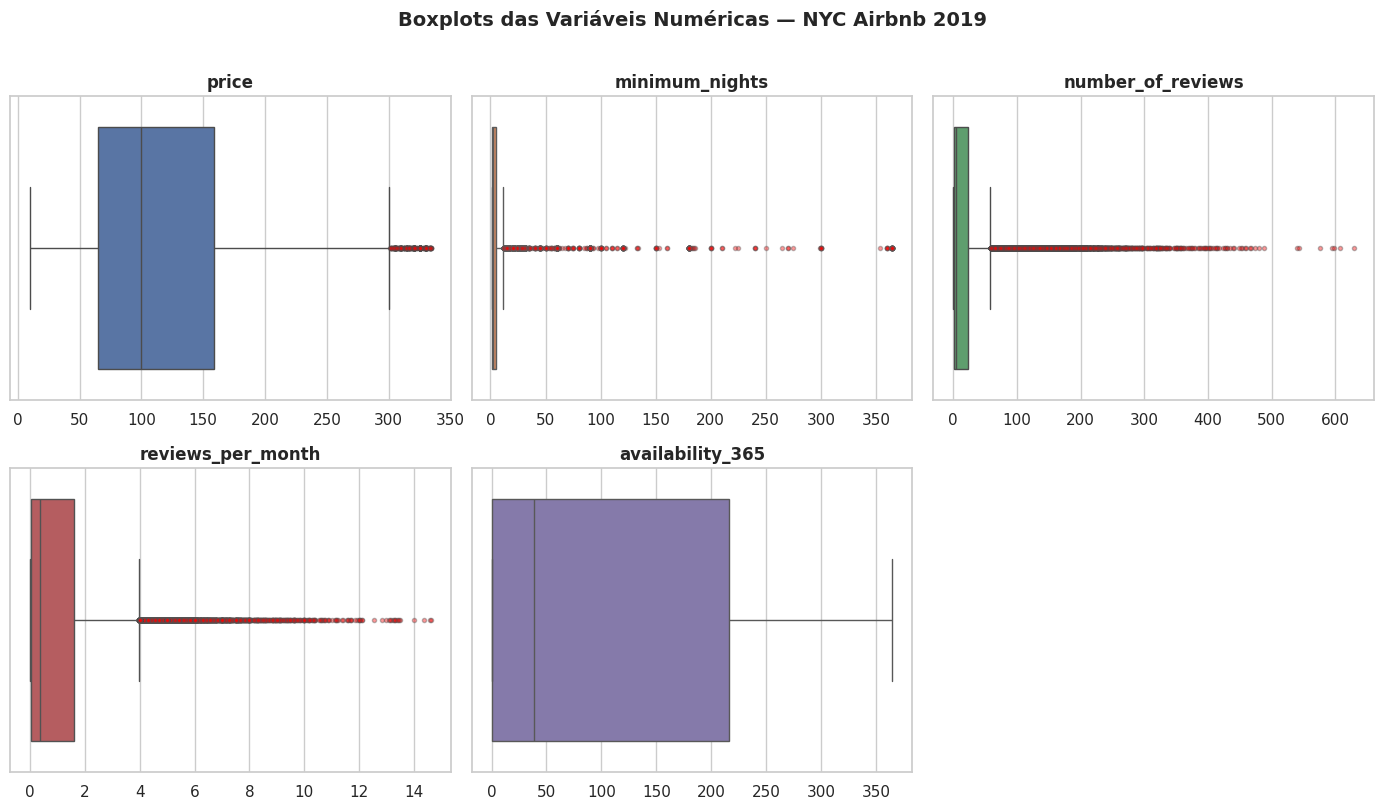

In [5]:
# 4.3 Boxplots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(
        data=df_tratado, x=col, ax=axes[i],
        color=cores[i],
        flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 3, 'alpha': 0.4}
    )
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

fig.delaxes(axes[5])
plt.suptitle('Boxplots das Variáveis Numéricas — NYC Airbnb 2019', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
### 05 Probabilidade em Análise de Dados

In [10]:
# 5.1 Probabilidades Simples
total = len(df_tratado)

p_caro = len(df_tratado[df_tratado['price'] > 200]) / total
p_entire = len(df_tratado[df_tratado['room_type'] == 'Entire home/apt']) / total
p_indisponivel = len(df_tratado[df_tratado['availability_365'] == 0]) / total
p_sem_review = len(df_tratado[df_tratado['number_of_reviews'] == 0]) / total

print('Probabilidades Simples: ')
print(f'Preço acima de $200:            {p_caro:.2%}')
print(f'Room Type - Entire home/apt:    {p_entire:.2%}')
print(f'Disponibilidade = 0 dias:       {p_indisponivel:.2%}')
print(f'Sem nenhuma review:             {p_sem_review:.2%}')

Probabilidades Simples: 
Preço acima de $200:            11.79%
Room Type - Entire home/apt:    49.64%
Disponibilidade = 0 dias:       36.68%
Sem nenhuma review:             19.61%


In [15]:
# 5.2 Probabilidade Condicional
manhattan = df_tratado[df_tratado['neighbourhood_group'] == 'Manhattan']
p_caro_dado_manhattan = len(manhattan[manhattan['price'] > 200]) / len(manhattan)

bronx = df_tratado[df_tratado['neighbourhood_group'] == 'Bronx']
p_caro_dado_bronx = len(bronx[bronx['price'] > 200]) / len(bronx)

caros = df_tratado[df_tratado['price'] > 200]
p_entire_dado_caro = len(caros[caros['room_type'] == 'Entire home/apt']) / len(caros)

indisponiveis = df_tratado[df_tratado['availability_365'] == 0]
p_sem_review_indisponivel = len(indisponiveis[indisponiveis['number_of_reviews'] == 0]) / len(indisponiveis)

print('Probabilidade Condicional: ')
print(f'Preços em Manhattan acima de $200:          {p_caro_dado_manhattan:.2%}')
print(f'Preços em Bronx acima de $200:              {p_caro_dado_bronx:.2%}')
print(f'Preços do Tipo Entire home acima de $200:   {p_entire_dado_caro:.2%}')
print(f'(sem review | disponib. = 0):               {p_sem_review_indisponivel:.2%}')

'''
Interpretação:
- Um imóvel em Manhattan tem muito mais chance de custar acima de $200 do que no Bronx, reflete a disparidade econômica entre regiões.
- Imóveis acima de $200 são quase todos Entire home/apt, faz sentido: quartos compartilhados raramente atingem esse preço.
- Imóveis com disponibilidade zero tendem a não ter reviews, provavelmente anúncios inativos ou recém-criados.
'''


Probabilidade Condicional: 
Preços em Manhattan acima de $200:          19.38%
Preços em Bronx acima de $200:              2.25%
Preços do Tipo Entire home acima de $200:   92.69%
(sem review | disponib. = 0):               26.63%


---
### 06 Análise Bivariada

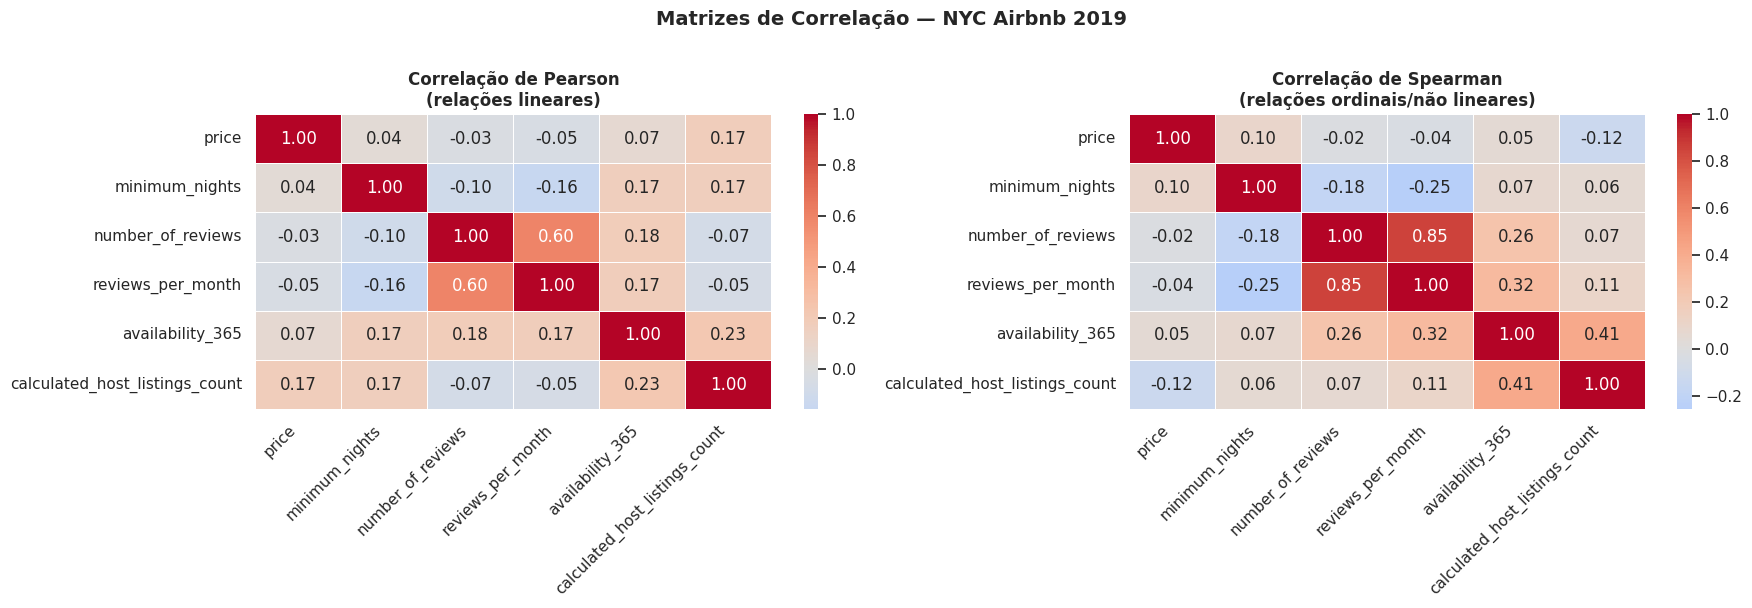

In [20]:
# 6.1 Correlação de Pearson e Spearman
cols_corr = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count']

pearson  = df_tratado[cols_corr].corr(method='pearson')
spearman = df_tratado[cols_corr].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(pearson,  annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Correlação de Pearson\n(relações lineares)', fontsize=12, fontweight='bold')

sns.heatmap(spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1], linewidths=0.5)
axes[1].set_title('Correlação de Spearman\n(relações ordinais/não lineares)', fontsize=12, fontweight='bold')

plt.suptitle('Matrizes de Correlação — NYC Airbnb 2019', fontsize=14, fontweight='bold', y=1.01)
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

'''
Interpretação:
- reviews_per_month e number_of_reviews têm correlação positiva, quanto mais reviews acumulados, mais por mês em média.
- price tem correlação fraca com a maioria das variáveis o preço é mais explicado por fatores categóricos (região, tipo de quarto) do que numéricos.
- availability_365 tem correlação negativa fraca com reviews_per_month — imóveis muito disponíveis tendem a ter menos reservas efetivas.
'''

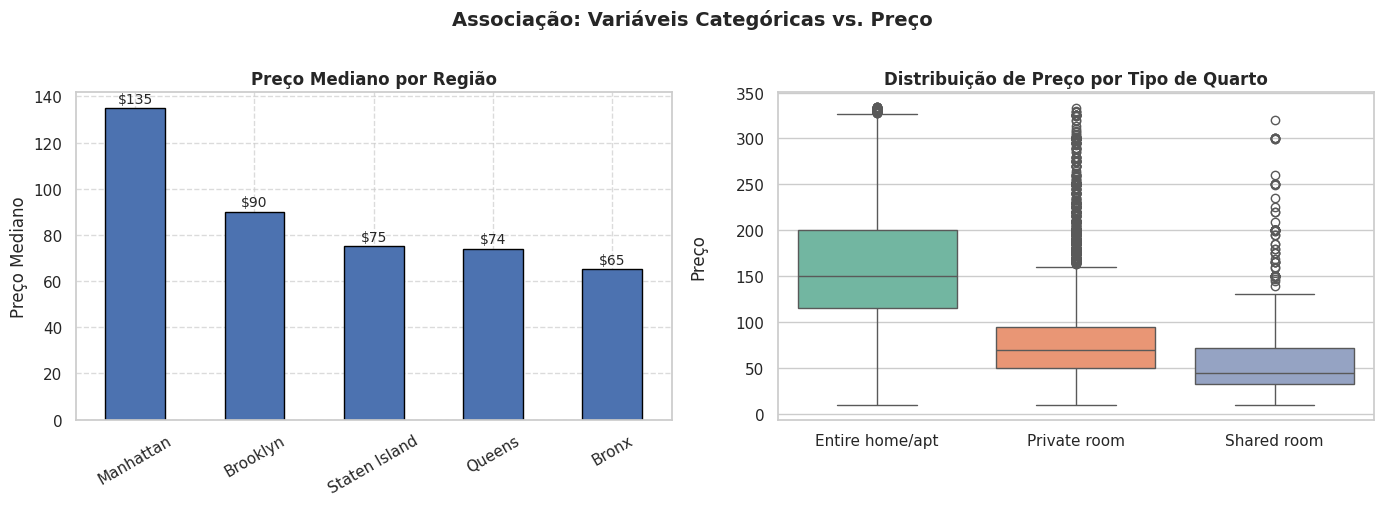

In [41]:
preco_por_regiao = df_tratado.groupby('neighbourhood_group', observed=True)['price'].median().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: preço mediano por região
preco_por_regiao.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Preço Mediano por Região', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Preço Mediano')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, linestyle='--', alpha=0.7)
for p in axes[0].patches:
    axes[0].annotate(f'${p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                     ha='center', va='bottom', fontsize=10)

# Gráfico 2: distribuição de preço por tipo de quarto
sns.boxplot(data=df_tratado, x='room_type', y='price', ax=axes[1],
palette='Set2', order=['Entire home/apt', 'Private room', 'Shared room'])
axes[1].set_title('Distribuição de Preço por Tipo de Quarto', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Preço',labelpad=20)
axes[0].grid(True, linestyle='--', alpha=0.7)


plt.suptitle('Associação: Variáveis Categóricas vs. Preço', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

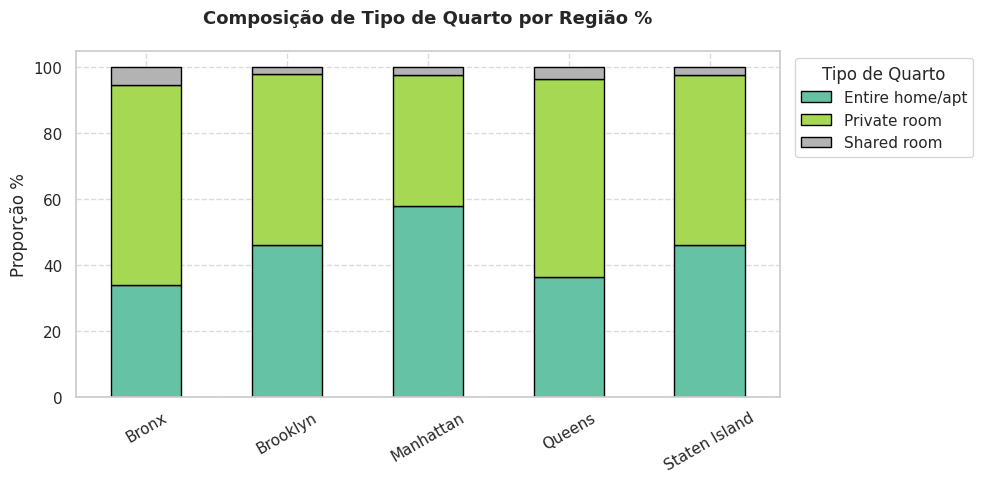

'\nInterpretação:\n- Manhattan tem o maior preço mediano, seguido de Brooklyn reflete a valorização imobiliária da ilha.\n- Entire home/apt custa consistentemente mais que Private room, que custa mais que Shared room relação intuitiva confirmada pelos dados.\n- Manhattan tem a maior proporção de Entire home/apt entre as regiões explica parcialmente seu preço mais alto.\n'

In [65]:
# 6.2 Gráfico de Barras Empilhadas: Composição de Tipo de Quarto por Região
contagem = df_tratado.groupby(['neighbourhood_group', 'room_type'], observed=True).size().unstack(fill_value=0)
contagem_pct = contagem.div(contagem.sum(axis=1), axis=0) * 100

contagem_pct.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Composição de Tipo de Quarto por Região %', fontsize=13, fontweight='bold', pad=20)
plt.xlabel('')
plt.ylabel('Proporção %')
plt.xticks(rotation=30)
plt.legend(title='Tipo de Quarto', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

'''
Interpretação:
- Manhattan tem o maior preço mediano, seguido de Brooklyn reflete a valorização imobiliária da ilha.
- Entire home/apt custa consistentemente mais que Private room, que custa mais que Shared room relação intuitiva confirmada pelos dados.
- Manhattan tem a maior proporção de Entire home/apt entre as regiões explica parcialmente seu preço mais alto.
'''

---
### 07 Visualização de Dados — Tipologia e Princípios

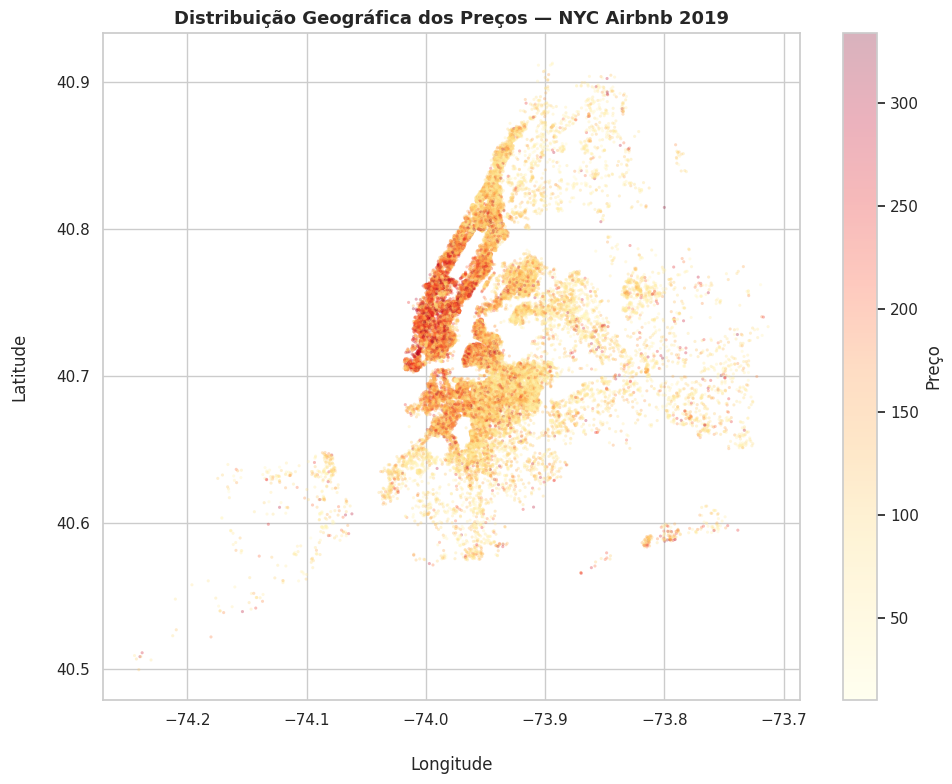

In [38]:
# 7.1 Distribuição geográfica dos preços (Relação espacial)
# Princípio de Tufte: só o necessário sem gridlines excessivas, sem chartjunk
# Princípio de Cleveland: posição ao longo de escala comum > área/cor para comparações

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(df_tratado['longitude'], df_tratado['latitude'],
c=df_tratado['price'], cmap='YlOrRd',alpha=0.3, s=5, linewidths=0)

plt.colorbar(scatter, ax=ax, label='Preço')
ax.set_title('Distribuição Geográfica dos Preços — NYC Airbnb 2019', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude', labelpad=20)
ax.set_ylabel('Latitude', labelpad=20)
ax.tick_params(left=False, bottom=False)

plt.tight_layout()
plt.show()

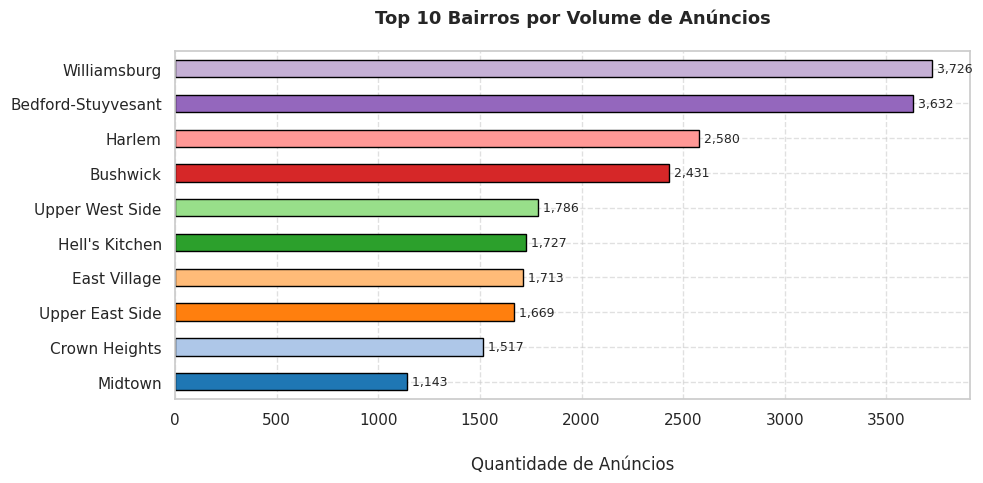

In [66]:
# 7.2 Top 10 bairros por volume de anúncios (Comparação)
# Princípio de Gestalt: proximidade e similaridade — barras ordenadas facilitam comparação
top10 = df_tratado['neighbourhood'].value_counts().head(10)
top10_sortiado = top10.sort_values()
fig, ax = plt.subplots(figsize=(10, 5))

#ex: 'viridis', 'magma', 'Paired', 'tab10')
cores = sns.color_palette('tab20')
top10_sortiado.plot(kind='barh', ax=ax, edgecolor='black', color=cores)
ax.set_title('Top 10 Bairros por Volume de Anúncios', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Quantidade de Anúncios', labelpad=20)
ax.set_ylabel('')
ax.grid(True, linestyle='--', alpha=0.6)

for y, value in enumerate(top10_sortiado.values):
    ax.annotate(f' {int(value):,}', (value + 5, y), va='center', fontsize=9)

plt.tight_layout()
plt.show()

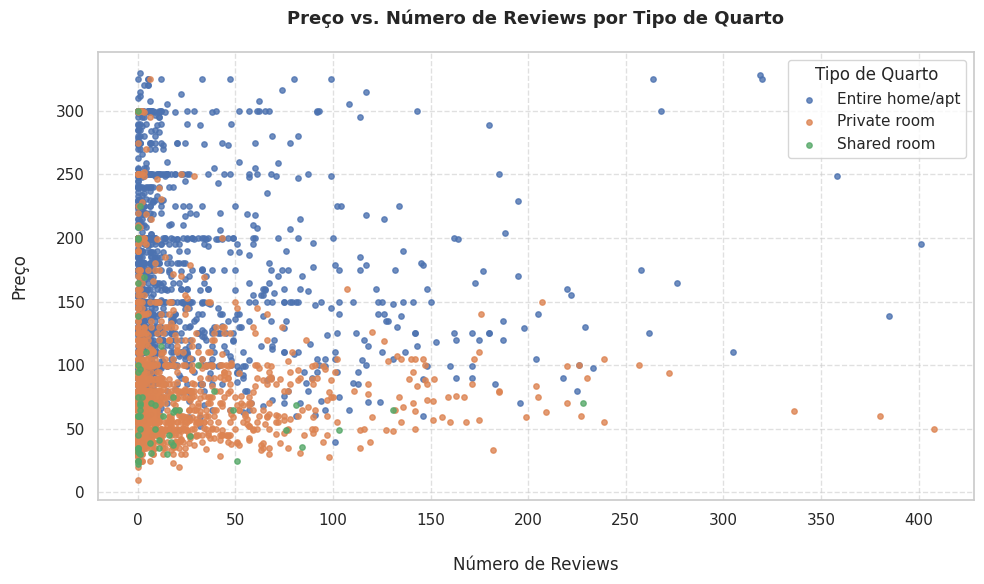

In [ ]:
# 7.3 Preço vs. Número de Reviews (Relação)
# Hierarquia de Cleveland & McGill: posição ao longo de eixo comum é mais precisa que área
# Amostra de 3000 pontos para evitar overplotting (Tufte: Data-Ink Ratio)

amostra = df_tratado.sample(3000, random_state=42)
fig, ax = plt.subplots(figsize=(10, 6))

for tipo, grupo in amostra.groupby('room_type', observed=True):
    ax.scatter(grupo['number_of_reviews'], grupo['price'],
        alpha=0.8, s=15, label=tipo)

ax.set_title('Preço vs. Número de Reviews por Tipo de Quarto', fontsize=13, fontweight='bold',pad=20)
ax.set_xlabel('Número de Reviews', labelpad=20)
ax.set_ylabel('Preço', labelpad=20)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Tipo de Quarto')

plt.tight_layout()
plt.show()

---
### 8 Relatório Final de Insights

O que os dados revelam sobre o mercado Airbnb em Nova York: 

1. Preço é fortemente determinado pela localização e tipo de imóvel manhattan concentra os imóveis mais caros, enquanto o Bronx apresenta os mais acessíveis. Imóveis inteiros custam em média 2x mais que quartos privados, que por sua vez custam 2x mais que quartos compartilhados.

2. Distribuições são assimétricas a mediana é mais confiável que a média todas as variáveis numéricas principais apresentam assimetria positiva. A média de preço é 20% maior que a mediana, indicando que poucos imóveis caros puxam a média para cima. Para comunicar o "preço típico", a mediana é a métrica correta.

3. A maioria dos anúncios tem pouquíssimas avaliações mais de 20% dos imóveis não têm nenhuma avaliação, e a mediana de reviews por mês é apenas 0.38 indicando baixa taxa de conversão ou muitos anúncios inativos.

4. Correlações numéricas são fracas o contexto categórico explica mais o coeficiente de Pearson entre price e number_of_reviews é próximo de zero. Isso significa que não existe relação linear entre preço e popularidade um imóvel caro não é necessariamente mais ou menos avaliado.

5. Williamsburg e Bedford-Stuyvesant dominam em volume os dois bairros do Brooklyn lideram em número de anúncios, superando inclusive bairros tradicionais de Manhattan como Hell's Kitchen reflexo da gentrificação e da busca por acomodações mais acessíveis próximas ao centro.

---
### Exportação do Dataset Tratado - Parte 2 (final)

In [76]:
from datetime import date
from pathlib import Path

AUTORIZAR_EXPORTACAO = True
if AUTORIZAR_EXPORTACAO:
    hoje = date.today().strftime('%Y%m%d')
    OUTPUT_DIR = Path('/home/joao/Área de trabalho/New York City Airbnb Open Data/data/data_tratado_02_completo')
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_FILE = OUTPUT_DIR / f'AB_NYC_2019_final_{hoje}.csv'

    df_tratado.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')

    print(f'✅ Exportado CVS final: {OUTPUT_FILE}')
    print(f'   {df_tratado.shape[0]} linhas × {df_tratado.shape[1]} colunas')
else:
    print('Exportação não autorizada. Nenhum CSV tratado foi gerado.')

✅ Exportado CVS final: /home/joao/Área de trabalho/New York City Airbnb Open Data/data/data_tratado_02_completo/AB_NYC_2019_final_20260420.csv
   45852 linhas × 16 colunas
